# **Part 1 - Data Understanding**



**Question 1**

Load the dataset and perform an initial exploration.

Identify:

*   Number of rows and columns
*   Data types of each variable
*   Any missing values in the dataset




Explain what each major column represents.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from google.colab import files
uploaded = files.upload()


Saving Retail Business Performance Analysis.csv to Retail Business Performance Analysis.csv


In [ ]:
df = pd.read_csv('Retail Business Performance Analysis.csv', encoding="latin1")


#rows and columns
print("Shape: ", df.shape)

#Data types
print("\nData Types:\n", df.dtypes)

#Missing values
print("\nMissing Values: \n", df.isnull().sum())

#first 5 rows
print("\nFirst 5 rows\n")
df.head()


Shape:  (9994, 21)

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values: 
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Question 2**

Using Python logic, write a function that categorizes orders into Low, Medium, or High sales orders based on the sales value.
Create a new column called Sales_Category.

In [ ]:
#in order to determine the threshold used for the sales category I looked at the stats of this dataset
print("Sales Mean",df["Sales"].mean())
print("Sales Median", df["Sales"].median())
print("Sales Standard Deviation",df["Sales"].std())
print("Sales Max Value",df["Sales"].max())
print("Sales Min Value",df["Sales"].min())

Sales Mean 229.85800083049833
Sales Median 54.489999999999995
Sales Standard Deviation 623.2451005086818
Sales Max Value 22638.48
Sales Min Value 0.444


In [ ]:
#function to define low/medium/high
def sales_category(sales):
  if sales < 60:
    return "Low"
  elif sales < 300:
    return "Medium"
  else:
    return "High"

#creating a new column
df["Sales_Category"] = df["Sales"].apply(sales_category)

#sanity check
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Sales_Category
0,1,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Medium
1,2,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,High
2,3,CA-2016-138688,6/12/2016,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Low
3,4,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,High
4,5,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Low


**Question 3**
Create a new column called Profit Margin using the formula:

Profit Margin = Profit / Sales

Explain what this metric indicates about product performance.


In [ ]:
df["Profit Margin (%)"] = ((df["Profit"] / df["Sales"])*100)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Sales_Category,Profit Margin (%)
0,1,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Medium,16.00
1,2,CA-2016-152156,11/8/2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,High,30.00
2,3,CA-2016-138688,6/12/2016,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Low,47.00
3,4,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,High,-40.00
4,5,US-2015-108966,10/11/2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Low,11.25


The profit margin metric indicates how much profit a product generates for every dollar of sales. Higher profit margin indicates that the product keeps more profit from each sale i.e. more efficient of a product. Lower profit margins indicate the opposite of high profit margins and may mean there is a higher cost. Negative Profit margins indicate that the product is actually losing money and that costs are higher than the revenue generated from sales.

# **Part 2 — Sales and Profit Analysis**

**Question 4**

Analyze total sales across different regions.
Identify:


*   Which region generates the highest revenue
*   Which region generates the lowest revenue



In [ ]:
#total sales across regions
total_sales = df.groupby("Region")["Sales"].sum()

print(total_sales)

print("\nRegion with Highest Sales :\n", total_sales.idxmax())

print("\nRegion with Lowest Sales :\n", total_sales.idxmin())

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Region with Highest Sales :
 West

Region with Lowest Sales :
 South


**Question 5**

Analyze the dataset to determine which product category generates the highest profit.


Also determine which subcategory contributes the most profit.


In [ ]:
#total profit acorss product and subproduct
category_profit = df.groupby("Category")["Profit"].sum()

print(category_profit)

print("\nCategory with Highest Profit :\n", category_profit.idxmax())


subproduct_profit = df.groupby("Sub-Category")["Profit"].sum()

print("\n==================\n")
print(subproduct_profit)

print("\nSub-Category with Highest Profit :\n", subproduct_profit.idxmax())

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

Category with Highest Profit :
 Technology


Sub-Category
Accessories    41936.6357
Appliances     18138.0054
Art             6527.7870
Binders        30221.7633
Bookcases      -3472.5560
Chairs         26590.1663
Copiers        55617.8249
Envelopes       6964.1767
Fasteners        949.5182
Furnishings    13059.1436
Labels          5546.2540
Machines        3384.7569
Paper          34053.5693
Phones         44515.7306
Storage        21278.8264
Supplies       -1189.0995
Tables        -17725.4811
Name: Profit, dtype: float64

Sub-Category with Highest Profit :
 Copiers


**Question 6**

Identify the top 10 most profitable products in the dataset.
Explain why these products might be performing well.


In [ ]:
#grouby prduct name and sum of profit

top_products = df.groupby("Product Name")["Profit"].sum()

#sort in dec order to get top ten
top_products = top_products.sort_values(ascending=False)

top_ten = top_products.head(10)

print("\nThe Top Ten Products with the Higest Profits are: \n",top_ten)


The Top Ten Products with the Higest Profits are: 
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


# **Part 3- Time Trend Analysis**

**Question 7 **

Extract year and month from the order date.

Analyze

*   Monthly Sales Trend
*   Yearly Sales Trend

Identify any seasonal patterns in sales.



In [ ]:
#extract Month and year
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.month
df["Year"] = df["Order Date"].dt.year

#monthly sales trend
monthly_sales = df.groupby("Month")["Sales"].sum()
print("\nMonthly Sales Trend: \n", monthly_sales)
print("\nBest Performing Month\n", monthly_sales.idxmax())
print("\nWorst performing Month\n", monthly_sales.idxmin())

print("\n==================\n")

#yearly sales trend
yearly_sales = df.groupby("Year")["Sales"].sum()
print("\nYearly Sales Trend: \n", yearly_sales)
print("\nBest Performing Year\n", yearly_sales.idxmax())
print("\nWorst performing Year\n", yearly_sales.idxmin())


Monthly Sales Trend: 
 Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

Best Performing Month
 11

Worst performing Month
 2



Yearly Sales Trend: 
 Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Best Performing Year
 2017

Worst performing Year
 2015


**Monthly Sales Trend Analysis**

The monthly sales analysis shows that though there is a significant variation through out the year, sales peak in November with the highest sales (\$353,461),  followed by December(\$325,293) and September(\$307,649). This shows that sales tend to peak toward the end of the year.

In contract the lowest sales month was in February(\$59,751) though after this month sales began to increase afterwards and remain relatively strong for the rest of the months. This then indicates that sales increase in the fall and winter months, possibly due to holiday purchasing and major shopping events.


**Yearly Sales Trend Analysis**
Overall the yearly sales analysis shows that sales typically increase through over the years. The lowest performing year was in 2015 (\$470,532) but shows a significant increase in the following years. Which indicates consistant growth in business performance over the years with expanding sales, improved market performance, and a higher customer demand.

**Seasonal Trend Analysis**

Through our monthly sales analysis we can conclude that there is a clear seasonal pattern when it comes to the product sold. The highest sales tend to occur in the later half of the year September- December, in particular the highest sales can be seen in November and December possibly due to holiday shopping and more marketing due to said holidays and year-end sales.

The first two months show the lowest record in sales which indicate that there is a reduction in consumer spending in the early part of the year.

# **Part 4 — Visualization (Matplotlib)**

**Question 8**

Create a bar chart showing total sales by region.
Explain which region performs best.


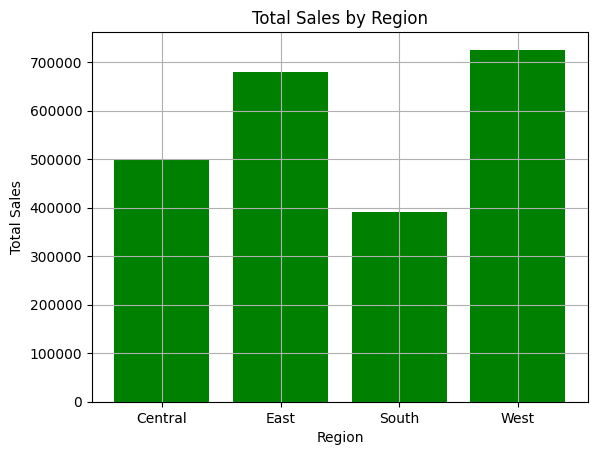

In [ ]:

#bar chart total sales taken from groupby produced earlier for total sales by region
plt.bar(total_sales.index, total_sales.values, color='green')
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region")
plt.grid(True)
plt.show()

**Regional Sale Analysis**

According to the bar chart and our analysis it is fair to say that the region that performed best with sales is the Western region. With earlier analysis done we know that the total sales in the west are at (\$725457.82)

**Question 9**

Create a line chart showing the monthly sales trend.
Interpret whether sales increase during certain months.


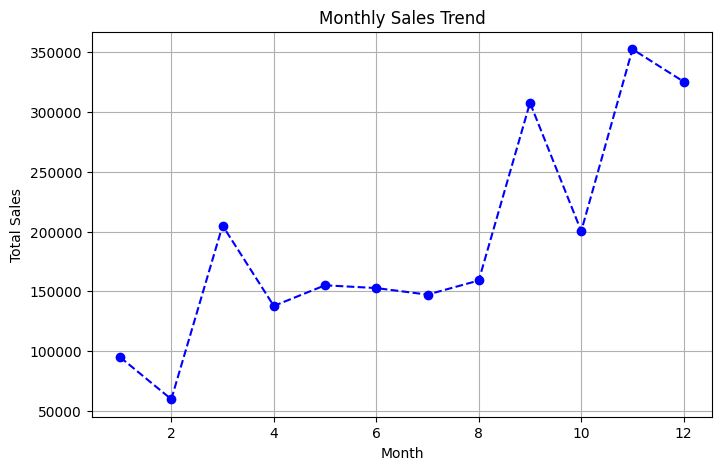

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='--', color='blue')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

**Monthly Sale Analysis**

According to the line chart there is a clear increase in sales in the later half of the year from around September-December. It also shows that sales tend to increase after February, the lowest sales record, which indicates that after the beginning of the year sales tend to increase.


**Question 10**

Create a bar chart comparing profit across product categories.
Explain which category contributes most to company profitability.


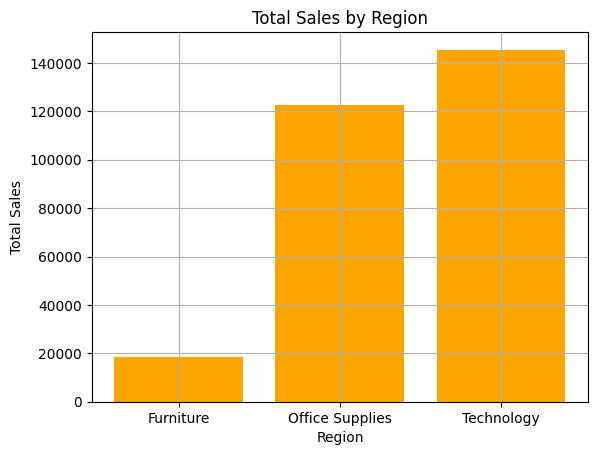

In [ ]:
plt.bar(category_profit.index, category_profit.values, color='orange')
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region")
plt.grid(True)
plt.show()

**Category Profit Analysis:**

Through this bar chart it is safe to say that the category that has the highest profit is Technology, followed by office supplies, and furniture being the lowest.

# **Part 5 — Visualization (Seaborn)**

**Question 11**

Create a scatter plot showing the relationship between Sales and Profit.
Interpret whether higher sales always result in higher profit.


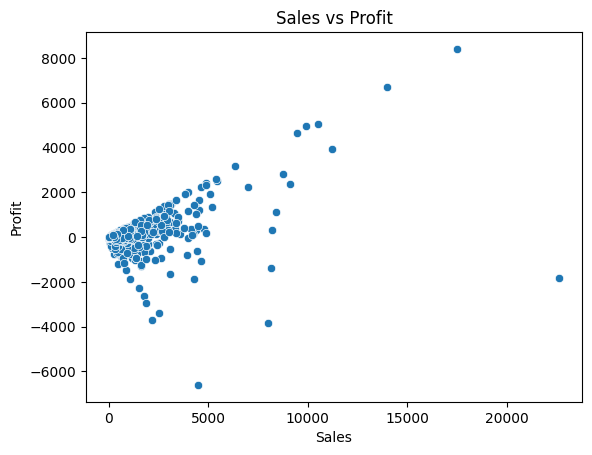

In [ ]:
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

**Sales vs Profit Analysis:**

While there is a general postive realtionship between sales and profit, higher sales do not always result in higher profit. This scatter plot shows that there are significate variances especially with the lower sales values. Some high value shows show that there is still a loss, possibly due to discounts. This goes to show that sales value alone is not a good predictor of profitbility.

**Question 12**

Create a box plot showing sales distribution across regions.
Identify whether any region contains significant outliers.


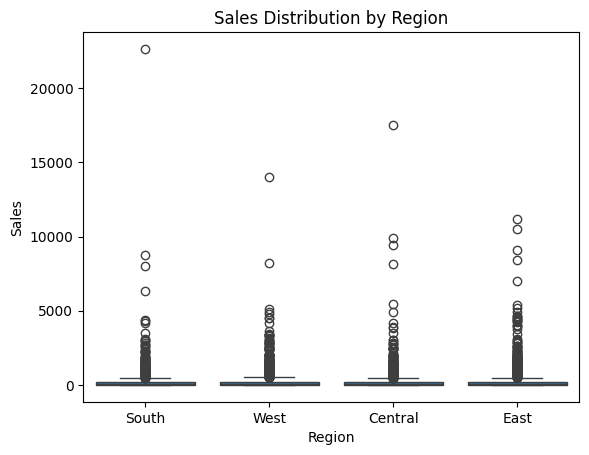

In [ ]:
sns.boxplot(x="Region", y="Sales", data=df)
plt.title("Sales Distribution by Region")
plt.show()

**Sales Distribution By Region Analysis**

All four regions contain significant outliers, indicating that occasional very high-value orders exist across the business. The South region contains the most extreme single outlier at approximately $22,500, which is notably higher than any other order in the dataset. The East region appears to have the highest number of outliers overall. The median sales values across all regions are relatively similar and low, with the bulk of orders clustered near the bottom

**Question 13**

Create a histogram showing the distribution of profit values.
Explain whether profit distribution is skewed or balanced.


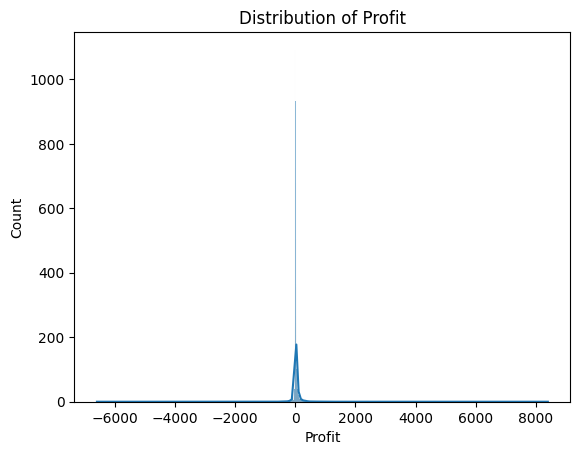

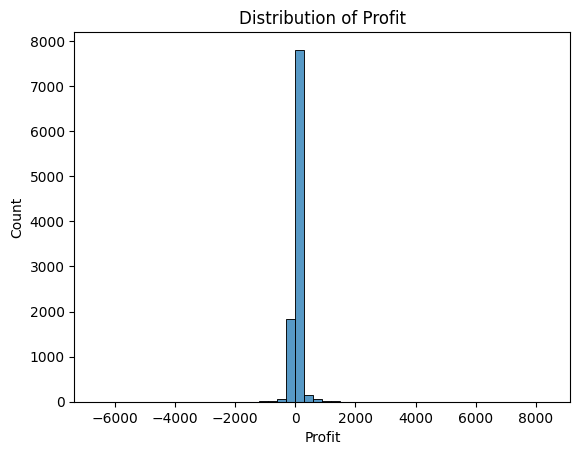

In [ ]:
sns.histplot(df["Profit"], kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.show()

#with bins to see better
sns.histplot(df["Profit"], bins=50)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.show()

**Profit Distribution Analysis**

The profit distribution is approximately centred near zero with a very high, narrow peak, indicating that the majority of orders generate modest profits. The distribution shows a slight right skew, with the positive tail extending further (\~$8,500) than the negative tail (\$~7,000). This suggests that while most transactions are low-profit, there are more extreme high-profit outliers than extreme losses.

**Question 14**

Create a correlation heatmap for all numerical variables.
Identify which variables have the strongest correlation.


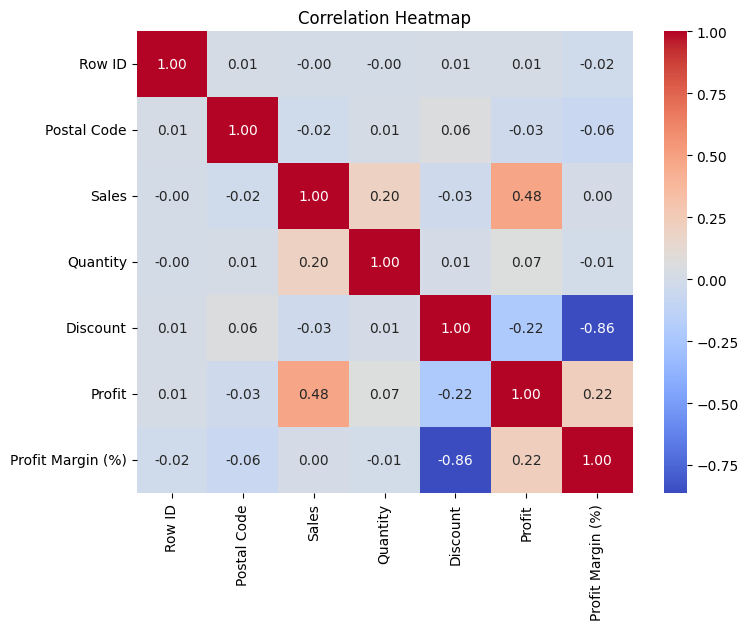

In [ ]:
#to do this first we need only the numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

#to get correlation matrix need to use .corr()
corr = numeric_df.corr()

#heatmap in sns is
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Correlation Analysis**

The strongest correlation in the dataset is between Discount and Profit Margin at -0.86, a strong negative relationship indicating that as discounts increase, profit margin decreases significantly. The second strongest correlation is between Sales and Profit at 0.48, a moderate positive relationship. Most other variable pairs show very weak or near-zero correlations, suggesting they have little linear relationship with each other

# **Part 6 — Statistical Analysis (SciPy)**

**Question 15**

Using SciPy, calculate the Pearson correlation coefficient between Sales and Profit.



*   Correlation Value
*   P-Value
*   Statistical Significance

Explain what this means for the business.


In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["Sales"], df["Profit"])

print("Correlation coefficient (r):", corr)
print("p-value:", p_value)

Correlation coefficient (r): 0.4790643497377061
p-value: 0.0


**Correlation Value:**

The Pearsons correlation coefficient measures the linear relationship between both Sales and Profit. This means that the closer the value is to +1 the stronger the positive relationship is. If the value is closer to 0 that means there is no correlation, and if it is closer to -1 the stronger the negative realtionship is.

In this evaltution the coefficient is at 0.48 which indicates  a moderate positive relationship between Sales and Profit. As sales increase, profits generally tend to increase as well, but the relationship is not extremely strong.

**P-Value:**

This value checks to see if the relationship is satistically significant. If the p value is less than 0.05 than it is signigicant while greater than idicates the opposite.

Here the value is roughly at 0 indicating that it is less than 0.05 meaning that there is a statistical significance.

**Statistical Value:**

Since the p-value is shown to be below 0.05 this means that the relationship between Sales and Profit is unlikely to have occurred by random chance.

**Business Insights:**

All in all from this analysis it shows that higher sales usually lead to higher profits, but sales alone do not fully determine profitability. Other factors such as discounts, product costs, and operational expenses may also impact profit levels.

# **Part 7 — Business Insights**

**Question 16**

**Which region should the company focus on for increasing revenue?**

The South has the lowest sales of the four regions at (\$391,721), compared to the West which leads with (\$725,457), followed by East at (\$678,781) and Central at (\$501,240). It would be in the best interest of the company to evaluate the marketing and sales strategies of the higher performing regions like the West and East, and assess whether similar approaches could be successfully applied to drive revenue growth in the South.

**Question 17**

**Which product category should the company invest more in?**


Based on the analysis done on product categories the product with the highest sales is Technology (\$145,454) total profit and should receive more investment to capitalise on its already strong returns. Within Technology, Copiers and Phones are the top performing sub-categories, suggesting further investment here would likely yield the greatest returns

**Question 18**

 **Are there any products that generate high sales but low profit?
Explain possible reasons.**

Yes, the scatter plot reveals several products that generate high sales but low or negative profit. Most notably, the highest sales order (\$22,500) actually results in a loss of approximately (-\$2,000.) Similarly, orders around (\$5,000–\$8,000) in sales also show significant losses. This contradicts the assumption that high sales always leads to profitability.
Possible reasons for this include:

Heavy discounting: supported by the heatmap which showed a strong -0.86 correlation between Discount and Profit Margin
High shipping costs on large or bulky orders, particularly in Furniture
Product mix:  selling high-volume but low-margin items like Tables, which were shown to have negative total profit earlier

**Question 19**

 **Does the company experience seasonal sales trends?
Provide supporting evidence**.


Yes, the monthly sales trend chart shows a clear seasonal pattern. Sales begin low in January (\~\$95,000) and hit their lowest point in February (\~\$60,000), suggesting reduced consumer spending at the start of the year. There is a notable spike in March (\~\$205,000) before settling to a relatively stable mid-range from April through August. Sales then surge significantly in the second half of the year, peaking in November (\~\$352,000), likely driven by holiday shopping and year-end promotions, before a slight decline in December. Overall, the second half of the year consistently outperforms the first, confirming a strong seasonal trend.

**Question 20**

**Provide five actionable recommendations to help the company increase profitability.**


1.   Invest in Southern region marketing — The South is the lowest performing region at (\$391,721) in sales. Evaluate the strategies used in the West (\$725,457) and East (\$678,781) and apply similar approaches to drive revenue growth in the South.

2.   Increase investment in Technology — Technology is the highest profit category at (\$145,454). Increasing marketing spend here, particularly on Copiers and Phones which are the top performing sub-categories, is likely to yield the strongest returns.

3.   Off-season marketing campaigns — January and February show the lowest sales in the year (\~\$60,000–\$95,000). Targeted promotions and discounts during this period could help smooth out the seasonal dip and maintain more consistent revenue year-round.

4. Review pricing on high-value orders — Several high sales orders still resulted in losses (notably the \~\$22,500 sale that generated -\$2,000 profit). The company should audit pricing on large orders to ensure they are actually profitable before fulfilling them.

5. Capitalise on the March spike — March shows an unexpected sales surge (\~\$205,000) in an otherwise quiet first half. Identifying what drives this and deliberately amplifying it through targeted campaigns could help reduce reliance on the end of year peak.
